# Figure 3: Chromatin and Gene Expression

**Goal:**

Show the relationship of the chromatin and gene expression with respect to cell phases. What patterns are different per cell phase?

**Procedure:**
1. Partition out the genes by where there maximal expression lies (criteria: expression is 1.5 greater in the phase than any other phase). Quantify this.
2. Then, plot the 90/10 PTR ratio for the chromatin for each of these highly expressed genes
3. Are there any discernible patterns in the chromatin for each cell phase?


In [3]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
# Load deconvolved gene expression
from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

gene_expression_dir = 'output/deconvolve_sharedg1_gopt_cc_2024_06_14/gene_expression/'
gene_expression_a = GeneExpressionAnalysis(gene_expression_dir)

In [5]:
from src.config import load_configs_by_config_type

config1, config2 = load_configs_by_config_type('shared')

g1_indices = config1.get_Hpositions_for_phase('CG1')
g2m_indices = config1.get_Hpositions_for_phase('G2M')
s_indices = config1.get_Hpositions_for_phase('S')

gene_expression = gene_expression_a.gene_expression_f

g1_exp = gene_expression[g1_indices]
g2m_exp = gene_expression[g2m_indices]
s_exp = gene_expression[s_indices]

max_g1_exp = g1_exp.max(axis=1)
max_s_exp = s_exp.max(axis=1)
max_g2m_exp = g2m_exp.max(axis=1)

g1_genes = gene_expression.loc[(max_g1_exp > max_s_exp) & 
                               (max_g1_exp > max_g2m_exp)].index
g2m_genes = gene_expression.loc[(max_g2m_exp > max_s_exp) & 
                                (max_g2m_exp > max_g1_exp)].index
s_genes = gene_expression.loc[(max_s_exp > max_g2m_exp) & 
                              (max_s_exp > max_g1_exp)].index

len(g1_genes), len(s_genes), len(g2m_genes)

(2283, 1088, 2207)

In [7]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_sharedg1_gopt_cc_2024_06_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)
promoter_analysis.load_f_files()

Shape of the loaded F: (178, 340)
(178, 340)
Shape of the adjusted F shape: (178, 374)
1/5578 - 00:00:00.026
1001/5578 - 00:00:08.925
2001/5578 - 00:00:18.609
3001/5578 - 00:00:29.143
4001/5578 - 00:00:51.976
5001/5578 - 00:01:30.286


In [47]:
from src.peak_to_trough import rescale_with_mapping, compute_quantile_ptr

img_size = 11, 34
    
def compute_gene_f_ptr(f_img_data):

    first_gene_f = f_img_data.reshape((178, -1))
    first_img = first_gene_f.reshape((-1, *img_size)).astype(float)
    from src.peak_to_trough import compute_ptr

    quantiles = 0.1, 0.9
    f_ptrs = np.zeros(first_gene_f.shape[1])
    
    config = config1

    c_indices = config.get_Hpositions_for_branch('t')
    c_timepoints = config.get_timepoints_for_branch('t')

    for i in range(first_gene_f.shape[1]):

        gene_f = first_gene_f[:, i]
        cg1_f = gene_f[c_indices]    
        cptr = compute_quantile_ptr(cg1_f, quantiles[0], quantiles[1])
        f_ptrs[i] = cptr

    return f_ptrs

In [48]:
from src.timer import Timer

timer = Timer()
n = len(promoter_analysis.all_gene_fs_df)
f_ptr_imgs = np.zeros((n, *img_size))

for i in range(n):
    f_img_data = promoter_analysis.all_gene_fs_df.iloc[i].values
    cur_f_ptrs = compute_gene_f_ptr(f_img_data)
    cur_f_ptr_img = cur_f_ptrs.reshape(img_size)
    f_ptr_imgs[i] = cur_f_ptr_img
    if i % 100 == 0:
        timer.print_time(f"{i}/{n}")


0/5578 - 00:00:00.137
100/5578 - 00:00:06.411
200/5578 - 00:00:12.627
300/5578 - 00:00:18.980
400/5578 - 00:00:25.638
500/5578 - 00:00:32.483
600/5578 - 00:00:40.610
700/5578 - 00:00:48.354
800/5578 - 00:00:55.884
900/5578 - 00:01:03.095
1000/5578 - 00:01:10.773
1100/5578 - 00:01:17.872
1200/5578 - 00:01:24.609
1300/5578 - 00:01:31.720
1400/5578 - 00:01:39.298
1500/5578 - 00:01:46.423
1600/5578 - 00:01:53.918
1700/5578 - 00:02:00.651
1800/5578 - 00:02:07.530
1900/5578 - 00:02:14.472
2000/5578 - 00:02:21.444
2100/5578 - 00:02:28.364
2200/5578 - 00:02:35.500
2300/5578 - 00:02:42.743
2400/5578 - 00:02:50.189
2500/5578 - 00:02:57.300
2600/5578 - 00:03:03.937
2700/5578 - 00:03:10.598
2800/5578 - 00:03:17.212
2900/5578 - 00:03:23.875
3000/5578 - 00:03:30.758
3100/5578 - 00:03:37.987
3200/5578 - 00:03:45.147
3300/5578 - 00:03:52.068
3400/5578 - 00:03:58.893
3500/5578 - 00:04:05.603
3600/5578 - 00:04:12.298
3700/5578 - 00:04:19.142
3800/5578 - 00:04:25.839
3900/5578 - 00:04:32.550
4000/5578 - 

In [51]:
f_ptr_imgs.shape

(5578, 11, 34)

In [54]:
genes_indices = gene_expression[[]].copy()
genes_indices['gene_index'] = np.arange(len(genes_indices))
genes_indices.head()

,gene_index
orf_name,
YAL067W-A,0
YAL067C,1
YAL064C-A,2
YAL064W,3
YAL063C-A,4


In [127]:
# Show chromatin PTR for these gene segments

# G1, for the highest express G1 genes, what does the PTR chromatin look like?
k = 50
top_k_g1_genes = gene_expression.loc[g1_genes][g1_indices].median(axis=1).sort_values(ascending=False).head(k).index
top_k_s_genes = gene_expression.loc[s_genes][s_indices].median(axis=1).sort_values(ascending=False).head(k).index
top_k_g2m_genes = gene_expression.loc[g2m_genes][g2m_indices].median(axis=1).sort_values(ascending=False).head(k).index

bottom_k_g1_genes = gene_expression.loc[g1_genes][g1_indices].median(axis=1).sort_values(ascending=False).tail(k).index
bottom_k_s_genes = gene_expression.loc[s_genes][s_indices].median(axis=1).sort_values(ascending=False).tail(k).index
bottom_k_g2m_genes = gene_expression.loc[g2m_genes][g2m_indices].median(axis=1).sort_values(ascending=False).tail(k).index


In [128]:
top_g1_gene_indices = genes_indices.loc[top_k_g1_genes].gene_index.values
top_s_gene_indices = genes_indices.loc[top_k_s_genes].gene_index.values
top_g2m_gene_indices = genes_indices.loc[top_k_g2m_genes].gene_index.values

bottom_g1_gene_indices = genes_indices.loc[bottom_k_g1_genes].gene_index.values
bottom_s_gene_indices = genes_indices.loc[bottom_k_s_genes].gene_index.values
bottom_g2m_gene_indices = genes_indices.loc[bottom_k_g2m_genes].gene_index.values

Text(0.5, 0.98, 'Top 50 highest expressed')

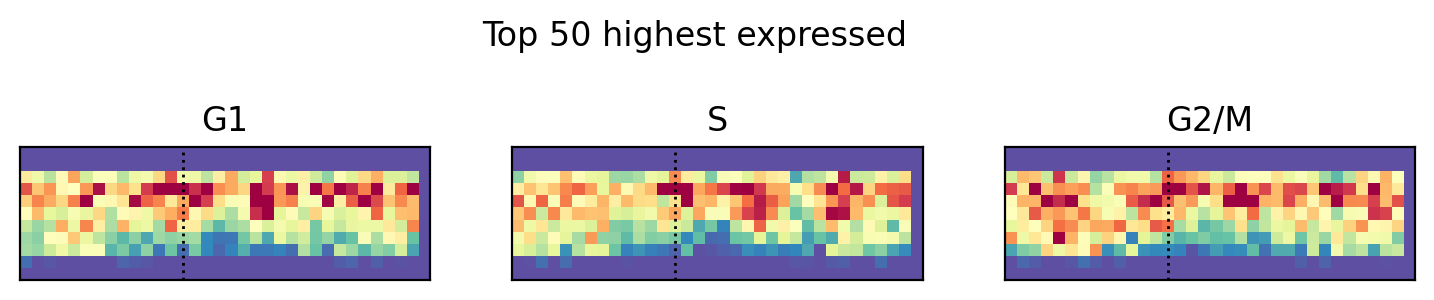

In [129]:
plt.figure(figsize=(9, 2))
plt.subplot(1, 3, 1)
plt.imshow(f_ptr_imgs[top_g1_gene_indices].mean(axis=0), origin='lower', 
                      cmap='Spectral_r', vmin=1, vmax=3)
plt.axvline(13, lw=1, ls='dotted', c='black')
plt.title("G1")
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(f_ptr_imgs[top_s_gene_indices].mean(axis=0), origin='lower', 
           cmap='Spectral_r', vmin=1, vmax=3)
plt.axvline(13, lw=1, ls='dotted', c='black')
plt.title("S")
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(f_ptr_imgs[top_g2m_gene_indices].mean(axis=0), origin='lower', 
                      cmap='Spectral_r', vmin=1, vmax=3)
plt.axvline(13, lw=1, ls='dotted', c='black')
plt.title("G2/M")
plt.xticks([])
plt.yticks([])
plt.suptitle(f"Top {k} highest expressed")

Text(0.5, 0.98, 'Top 50 lowest expressed')

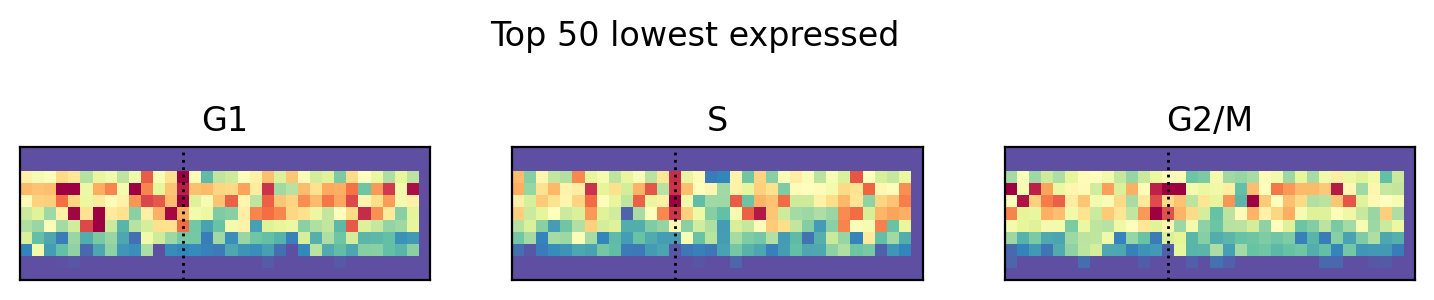

In [130]:
plt.figure(figsize=(9, 2))
plt.subplot(1, 3, 1)
plt.imshow(f_ptr_imgs[bottom_g1_gene_indices].mean(axis=0), origin='lower', 
                      cmap='Spectral_r', vmin=1, vmax=3)
plt.axvline(13, lw=1, ls='dotted', c='black')
plt.title("G1")
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(f_ptr_imgs[bottom_s_gene_indices].mean(axis=0), origin='lower', 
           cmap='Spectral_r', vmin=1, vmax=3)
plt.axvline(13, lw=1, ls='dotted', c='black')
plt.title("S")
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(f_ptr_imgs[bottom_g2m_gene_indices].mean(axis=0), origin='lower', 
                      cmap='Spectral_r', vmin=1, vmax=3)
plt.axvline(13, lw=1, ls='dotted', c='black')
plt.title("G2/M")
plt.xticks([])
plt.yticks([])
plt.suptitle(f"Top {k} lowest expressed")